#🌀⏱InceptionTime DEMO 📈

**InceptionTime** is a deep learning model designed for **time series classification**.

This demo uses **ItalyPowerDemand dataset** for binary classification:
- a univariate dataset from the **UCR/UEA archive** (https://www.timeseriesclassification.com/), a widely used benchmark for univariate time series.
- 1D sequences of electric power demand, each with 24 time steps
- two classes:
  - **Class 1:** normal weekday consumption pattern
  - **Class 2:** abnormal consumption (typically weekends or holidays)


Demo contains:
- brief dataset analysis/visualisation
- training with early stopping
- performance evaluation: metrics, learning dynamics, and representative class samples
- **classifier comparison:** InceptionTime, **ROCKET**, **k-NN DTW**




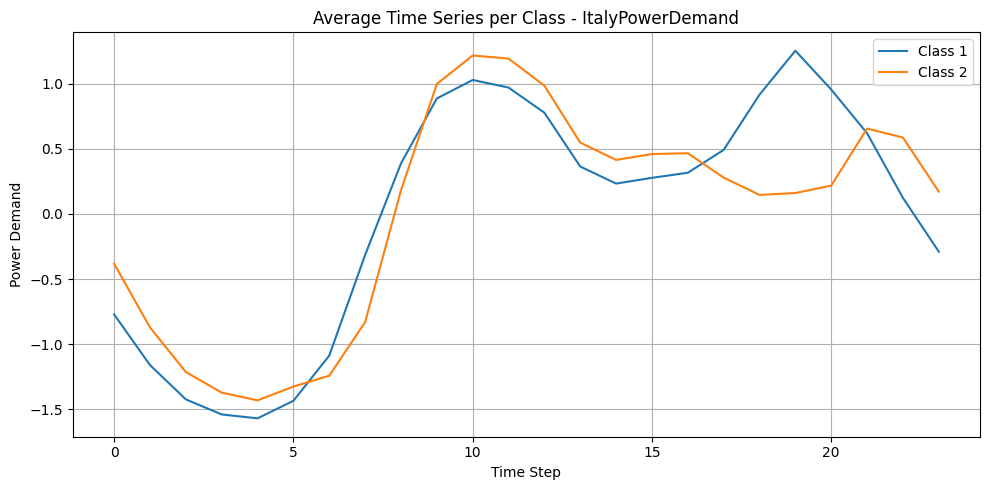

In [5]:
#!pip install sktime[dl]

from sktime.classification.deep_learning import InceptionTimeClassifier
from tensorflow.keras.callbacks import EarlyStopping
from sktime.datasets import load_UCR_UEA_dataset
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


X_train, y_train = load_UCR_UEA_dataset("ItalyPowerDemand", split="train", return_X_y=True)
X_test, y_test = load_UCR_UEA_dataset("ItalyPowerDemand", split="test", return_X_y=True)


# INSPECT DATASET - average time series for each class
X = pd.concat([X_train, X_test])
y = np.concatenate([y_train, y_test])

classes = np.unique(y)
mean_series = {}
for cls in classes:
    cls_series = X[y == cls]
    stacked = np.stack([row.values for row in cls_series.iloc[:, 0]])
    mean_series[cls] = np.mean(stacked, axis=0)

plt.figure(figsize=(10, 5))
for cls in classes:
    plt.plot(mean_series[cls], label=f"Class {cls}")
plt.title("Average Time Series per Class - ItalyPowerDemand")
plt.xlabel("Time Step")
plt.ylabel("Power Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 24: early stopping
Restoring model weights from the end of the best epoch: 14.


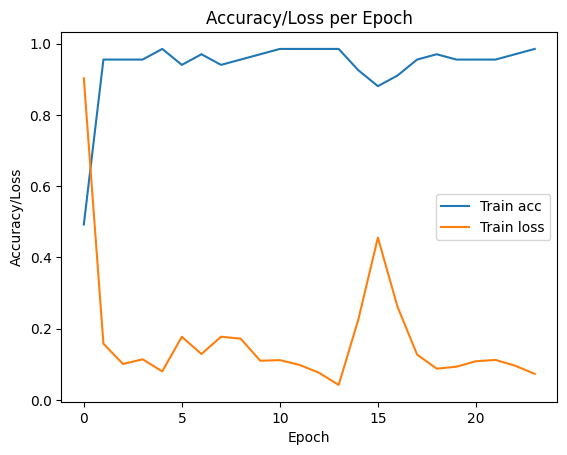

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step
Accuracy on test set: 0.89


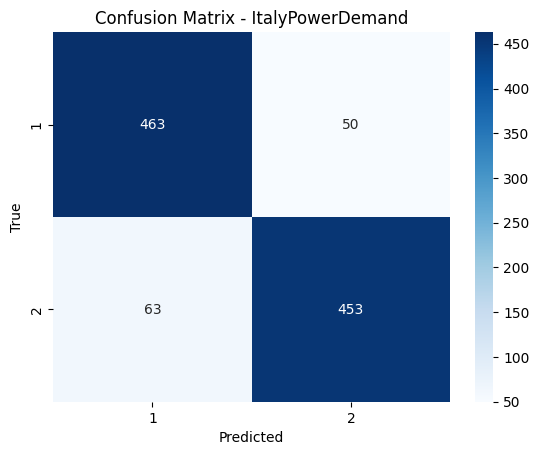

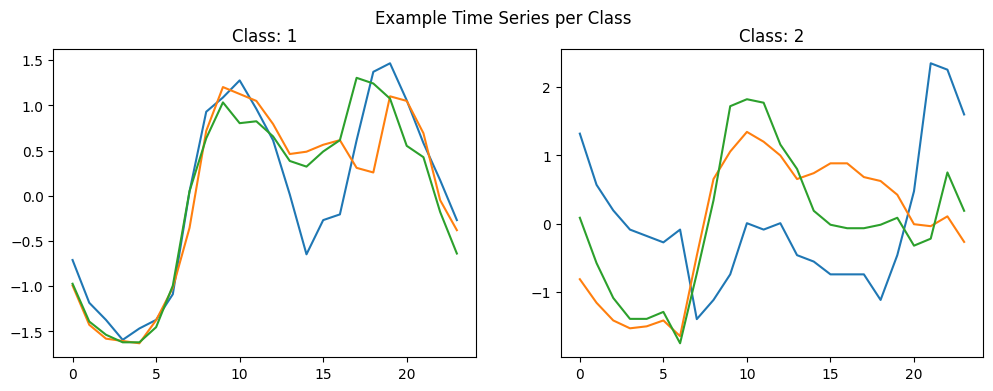

In [6]:
# TRAINING & EVAL

early_stop = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

clf= InceptionTimeClassifier(
    n_epochs=100,
    callbacks=[early_stop],
    verbose=True,   #set to False for shorter output
)

clf.fit(X_train, y_train)
history = clf.history


plt.plot(history.history["accuracy"], label="Train acc")
plt.plot(history.history["loss"], label="Train loss")
plt.legend()
plt.title("Accuracy/Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy/Loss")
plt.show()

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on test set: {acc:.2f}")


cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ItalyPowerDemand")
plt.show()



# Plot first 3 series from each class
classes = np.unique(y_train)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for i, cls in enumerate(classes):
    cls_series = X_train[y_train == cls].iloc[:3]
    for series in cls_series[cls_series.columns[0]]:
        axs[i].plot(series.values)
    axs[i].set_title(f"Class: {cls}")
plt.suptitle("Example Time Series per Class")
plt.show()




##COMPARISON

1. **ROCKET (RandOm Convolutional KErnel Transform)** - strong non-deep learning baseline for time series classification
- Applies thousands of random convolutional kernels to extract features from time series data.
- Transforms the input into a high-dimensional feature space using summary statistics (e.g., max, proportion of positive values).
- Uses a simple linear classifier (typically ridge regression) on top of these features.
- Extremely fast to train and performs well even on small or noisy datasets.


2. **k-NN with DTW (Dynamic Time Warping)** - classic baseline for evaluating shape-based pattern matching
- A distance-based classifier that compares time series directly using DTW, which aligns sequences with temporal shifts.
- No training phase; classification is based on similarity to labeled training examples.
- Performs well on datasets with small inter-class variation and shape-based differences.
- Highly interpretable, but computationally expensive for large datasets.


 Training: InceptionTime...
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 8.
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step
InceptionTime Accuracy: 0.96
Time: 21.39s

 Training: ROCKET...
ROCKET Accuracy: 0.97
Time: 27.30s

 Training: k-NN...
k-NN DTW Accuracy: 0.95
Time: 0.66s


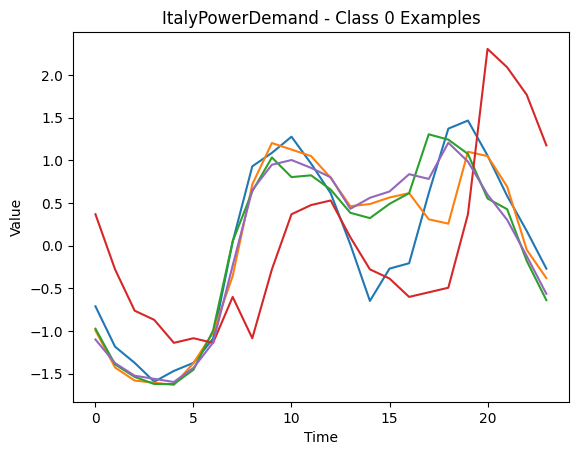

In [13]:
from sktime.classification.kernel_based import RocketClassifier
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
import time
import tensorflow as tf
from gc import collect


# Cleanup TF session
tf.keras.backend.clear_session()
collect()

# --- InceptionTime ---
early_stop = EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

clf= InceptionTimeClassifier(
    n_epochs=100,
    callbacks=[early_stop],
    verbose=False
)

print("\n Training: InceptionTime...")
start = time.time()
clf.fit(X_train, y_train)
y_pred_inception = clf.predict(X_test)
acc_inception = accuracy_score(y_test, y_pred_inception)
print(f"InceptionTime Accuracy: {acc_inception:.2f}")
print(f"Time: {time.time() - start:.2f}s")


# Cleanup TF session
tf.keras.backend.clear_session()
collect()

# --- ROCKET ---
print("\n Training: ROCKET...")
start = time.time()
clf_rocket = RocketClassifier()
clf_rocket.fit(X_train, y_train)
y_pred_rocket = clf_rocket.predict(X_test)
acc_rocket = accuracy_score(y_test, y_pred_rocket)
print(f"ROCKET Accuracy: {acc_rocket:.2f}")
print(f"Time: {time.time() - start:.2f}s")

# --- k-NN DTW ---
print("\n Training: k-NN...")
start = time.time()
clf_knn = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw")
clf_knn.fit(X_train, y_train)
y_pred_knn = clf_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"k-NN DTW Accuracy: {acc_knn:.2f}")
print(f"Time: {time.time() - start:.2f}s")

# Plot 5 examples from Class 0
y_train = pd.Series(y_train)
subset = X_train[y_train == y_train.iloc[0]].iloc[:5]
for i, row in subset.iterrows():
    plt.plot(row.iloc[0].values)
plt.title("ItalyPowerDemand - Class 0 Examples")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


# Comparison on NATOPS Dataset

**NATOPS dataset (https://www.timeseriesclassification.com/description.php?Dataset=NATOPS):**
  - a **multivariate time series classification** benchmark from UCR/UEA archive
  - contains **motion-capture recordings** of six different aircraft handling signals, performed by naval flight officers using hand gestures
  - instances: 360 training, 180 testing
  - length: 51 time steps per series
  - dimensions: 24 (motion sensor axes)
  - **classes: 6 distinct hand signals** (e.g., "Spread Wings", "Pull Back Stick"); subtle inter-class variation

In [16]:
# Load NATOPS dataset
X_train, y_train = load_UCR_UEA_dataset("NATOPS", split="train", return_X_y=True)
X_test, y_test = load_UCR_UEA_dataset("NATOPS", split="test", return_X_y=True)

# Cleanup TF session
tf.keras.backend.clear_session()
collect()

# --- InceptionTime ---
clf = InceptionTimeClassifier(
    n_epochs=300,
    batch_size=16,
    verbose=False
)

print("\n InceptionTime...")
start = time.time()
clf.fit(X_train, y_train)
y_pred_inception = clf.predict(X_test)
acc_inception = accuracy_score(y_test, y_pred_inception)
print(f"InceptionTime Accuracy: {acc_inception:.2f}")
print(f"Time: {time.time() - start:.2f}s")


tf.keras.backend.clear_session()
collect()

# --- ROCKET ---
print("\nROCKET...")
start = time.time()
clf_rocket = RocketClassifier()
clf_rocket.fit(X_train, y_train)
y_pred_rocket = clf_rocket.predict(X_test)
acc_rocket = accuracy_score(y_test, y_pred_rocket)
print(f"ROCKET Accuracy: {acc_rocket:.2f}")
print(f"Time: {time.time() - start:.2f}s")

# --- k-NN DTW ---
print("\n k-NN DTW...")
start = time.time()
clf_knn = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw")
clf_knn.fit(X_train, y_train)
y_pred_knn = clf_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"k-NN DTW Accuracy: {acc_knn:.2f}")
print(f"Time: {time.time() - start:.2f}s")




 InceptionTime...
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step
InceptionTime Accuracy: 0.98
Time: 534.95s

ROCKET...
ROCKET Accuracy: 0.88
Time: 45.80s

 k-NN DTW...
k-NN DTW Accuracy: 0.88
Time: 6.33s
